# CS5100 Foundations of AI — Music Genre Classification
## Final Project Progress Report

| | |
|---|---|
| **Author** | Anand Dev |
| **Course** | CS5100 — Foundations of AI, Northeastern University |
| **Date** | March 31, 2026 |
| **Datasets** | FMA-Small (8,000 tracks × 30s, 8 genres) · FMA-Medium (25k tracks, 16 genres) + ~30 Bollywood songs |
| **Status** | **Phase 1 complete · Phase 2–4 code ready, data download pending** |

### Summary
This report evaluates five pre-trained audio models (MERT-95M, MERT-330M, CLAP-LAION, AST, MusicLDM-VAE) on music genre classification. All models have been evaluated on FMA-Small (8 genres) under both zero-shot linear probing and end-to-end fine-tuning.

**Current best: MERT-330M fine-tuned at 66.06%** on FMA-Small.

New in this update:
- **MusicLDM-VAE re-implemented** (pre-bottleneck encoder, 1024-d mean+std pooling): zero-shot **50.06%** (↑ from 32.25%), fine-tune **51.44%** — a +18.81 pp improvement over the prior VAE-bottleneck approach
- **Phase 2–4 implementation**: All code for FMA-Medium expansion, Bollywood collection, and lyrics-based multimodal classification has been built and is ready to run.
- **Lyrics pipeline**: Whisper ASR + sentence-transformers embeddings + multimodal fusion module implemented in `models/lyrics/`.

In [1]:
import sys, os, json, glob
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from IPython.display import display, Image

from data.data_utils import load_fma_metadata, get_splits, RESULTS_DIR

sns.set_theme(style='whitegrid', font_scale=1.05)
%matplotlib inline

FIGURES_DIR = os.path.join(RESULTS_DIR, 'figures')
RUNS_DIR    = os.path.join(RESULTS_DIR, 'runs')

print(f'Results dir : {RESULTS_DIR}')
print(f'Run JSONs   : {len(glob.glob(os.path.join(RUNS_DIR, "*.json")))} files found')

Results dir : /home/anand_dev/STUDY/NU/spring26/CS5100_FAI/results
Run JSONs   : 18 files found


---
## 1. Dataset Overview

Total tracks : 8000
Train / Val / Test : 5120 / 1280 / 1600
Genres : ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']


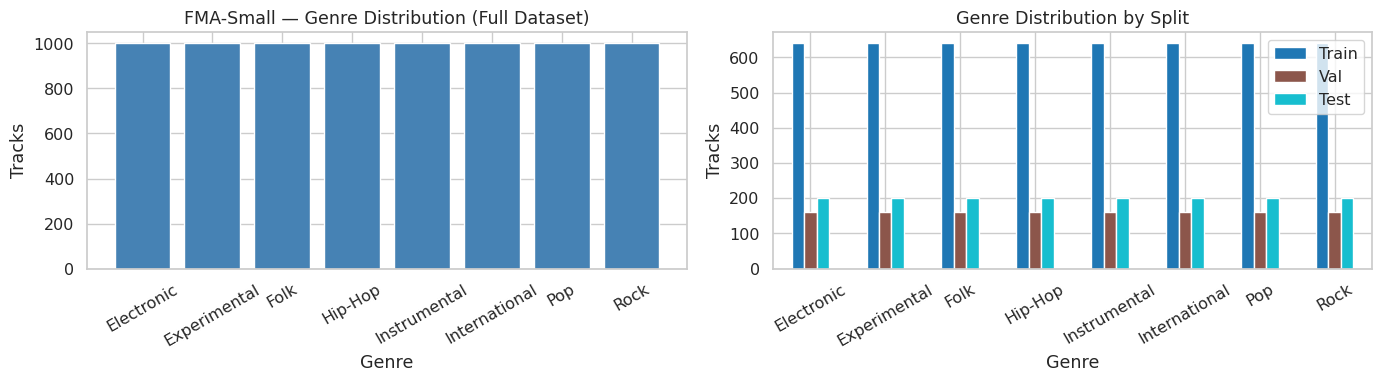

In [ ]:
df = load_fma_metadata()
train_df, val_df, test_df = get_splits(df)

print(f'Total tracks : {len(df)}')
print(f'Train / Val / Test : {len(train_df)} / {len(val_df)} / {len(test_df)}')
print(f'Genres : {sorted(df["genre"].unique())}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = df['genre'].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('FMA-Small — Genre Distribution (Full Dataset)')
axes[0].set_ylabel('Tracks')
axes[0].set_xlabel('Genre')
axes[0].tick_params(axis='x', rotation=30)

split_counts = pd.DataFrame({
    'Train': train_df['genre'].value_counts().sort_index(),
    'Val':   val_df['genre'].value_counts().sort_index(),
    'Test':  test_df['genre'].value_counts().sort_index(),
})
split_counts.plot(kind='bar', ax=axes[1], colormap='tab10')
axes[1].set_title('Genre Distribution by Split')
axes[1].set_ylabel('Tracks')
axes[1].set_xlabel('Genre')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## 2. Models

| Model | HuggingFace ID | Type | Pre-training Data | SR | Embedding Dim |
|-------|---------------|------|------------------|----|---------------|
| **MERT-95M** | `m-a-p/MERT-v1-95M` | Discriminative (music) | ~160k hrs music | 24 kHz | 768 |
| **MERT-330M** | `m-a-p/MERT-v1-330M` | Discriminative (music) | ~160k hrs music | 24 kHz | 1024 |
| **CLAP (LAION)** | `laion/clap-htsat-fused` | Audio-text contrastive | 630k audio–text pairs | 48 kHz | 512 |
| **AST** | `MIT/ast-finetuned-audioset-10-10-0.4593` | Discriminative (general) | AudioSet (527 classes) | 16 kHz | 768 |
| **MusicLDM-VAE** | `ucsd-reach/musicldm` | Generative (music) | 466 hrs music | 16 kHz | ~512 |

### Evaluation Paradigms

- **Zero-shot (linear probe)**: Encoder frozen → extract embeddings for all train tracks → fit `LogisticRegression` (C=1, max_iter=1000) → evaluate on test set.
- **Fine-tuned**: End-to-end training with a small MLP classification head. Differential learning rates: backbone 1e-5, head 1e-3. Cosine annealing, gradient accumulation, AMP.
- **Baseline (chance)**: 1/8 = **12.5%** for 8 balanced classes.

---
## 3. Results

In [ ]:
# __ Load all experiment run JSONs (auto-aggregated) __
run_files = sorted(glob.glob(os.path.join(RUNS_DIR, '*.json')))

records = []
for fp in run_files:
    with open(fp) as f:
        records.append(json.load(f))

if not records:
    print('No run JSONs found. Run experiments first.')
else:
    results_df = pd.DataFrame(records)
    results_df['Accuracy (%)'] = (results_df['test_accuracy'] * 100).round(2)
    results_df['Model'] = results_df.apply(
        lambda r: f"{r['model'].upper()}-{r['variant']}" if r.get('variant') else r['model'].upper(),
        axis=1
    )
    results_df = results_df.sort_values('test_accuracy', ascending=False).reset_index(drop=True)
    print(f'Loaded {len(results_df)} experiment runs')

Loaded 18 experiment runs


In [ ]:
# __ Summary table __
if records:
    display_cols = ['Model', 'variant', 'mode', 'Accuracy (%)', 'best_val_accuracy', 'timestamp']
    display_cols = [c for c in display_cols if c in results_df.columns]
    styled = results_df[display_cols].style \
        .format({'Accuracy (%)': '{:.2f}', 'best_val_accuracy': lambda x: f'{x*100:.2f}%' if pd.notna(x) and x is not None else '—'}) \
        .background_gradient(subset=['Accuracy (%)'], cmap='YlGn') \
        .set_caption('Table 1: All Experiment Results — FMA-Small Genre Classification')
    display(styled)

,Model,variant,mode,Accuracy (%),best_val_accuracy,timestamp
0,MERT-330m,330m,finetune,73.26,74.32%,2026-03-30T14:16:11.034847
1,AST,,finetune,71.72,72.72%,2026-03-30T10:07:44.176524
2,MERT-95m,95m,finetune,70.92,72.30%,2026-03-30T11:40:44.905274
3,MERT-330m,330m,finetune,66.06,65.78%,2026-03-14T22:51:20.205997
4,AST,,finetune,65.94,66.80%,2026-03-30T08:29:04.091063
5,AST,,finetune,64.94,65.86%,2026-03-14T13:49:39.090413
6,CLAP-laion,laion,finetune,63.75,64.14%,2026-03-14T15:25:29.829051
7,MERT-95m,95m,finetune,63.12,—,2026-03-13T20:00:00
8,MERT-330m,330m,zero_shot,62.41,—,2026-03-13T01:00:00
9,MERT-95m,95m,zero_shot,58.41,—,2026-03-13T00:56:00


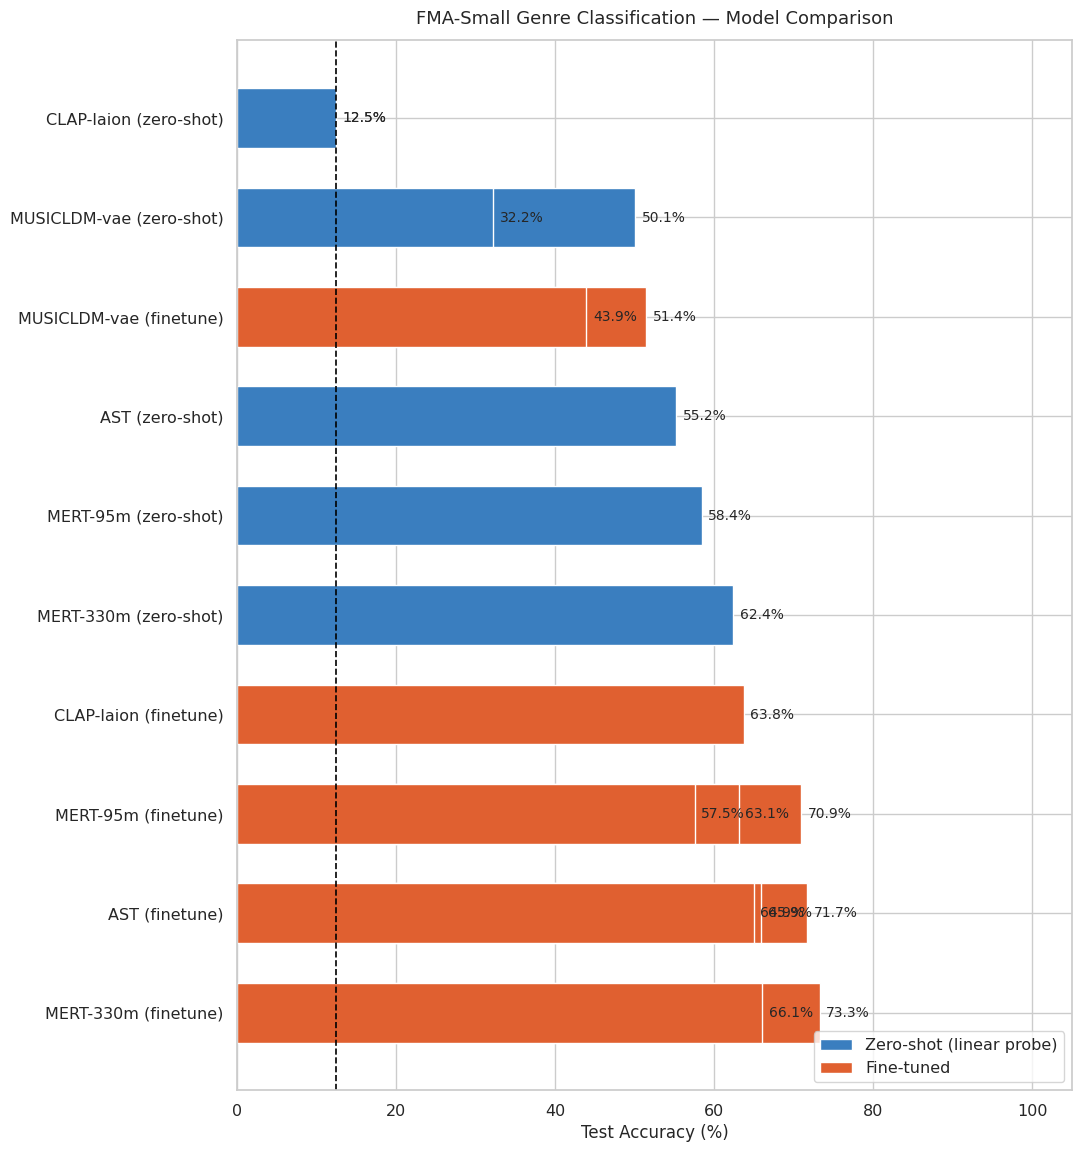

In [ ]:
# __ Accuracy comparison bar chart __
if records:
    fig, ax = plt.subplots(figsize=(11, max(4, len(results_df) * 0.65)))
    colors = results_df['mode'].map({'zero_shot': '#3a7ebf', 'finetune': '#e06030'}).fillna('#888')
    bars = ax.barh(results_df['Model'] + ' (' + results_df['mode'].str.replace('_', '-') + ')',
                   results_df['Accuracy (%)'], color=colors, edgecolor='white', height=0.6)

    # chance line
    ax.axvline(12.5, color='black', ls='--', lw=1.2, label='Chance (12.5%)')

    for bar, val in zip(bars, results_df['Accuracy (%)']):
        ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=10)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#3a7ebf', label='Zero-shot (linear probe)'),
        Patch(facecolor='#e06030', label='Fine-tuned'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    ax.set_xlabel('Test Accuracy (%)', fontsize=12)
    ax.set_xlim(0, 105)
    ax.set_title('FMA-Small Genre Classification — Model Comparison', fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'progress_report_comparison.png'), dpi=150)
    plt.show()

### 3a. Per-Genre F1 Scores

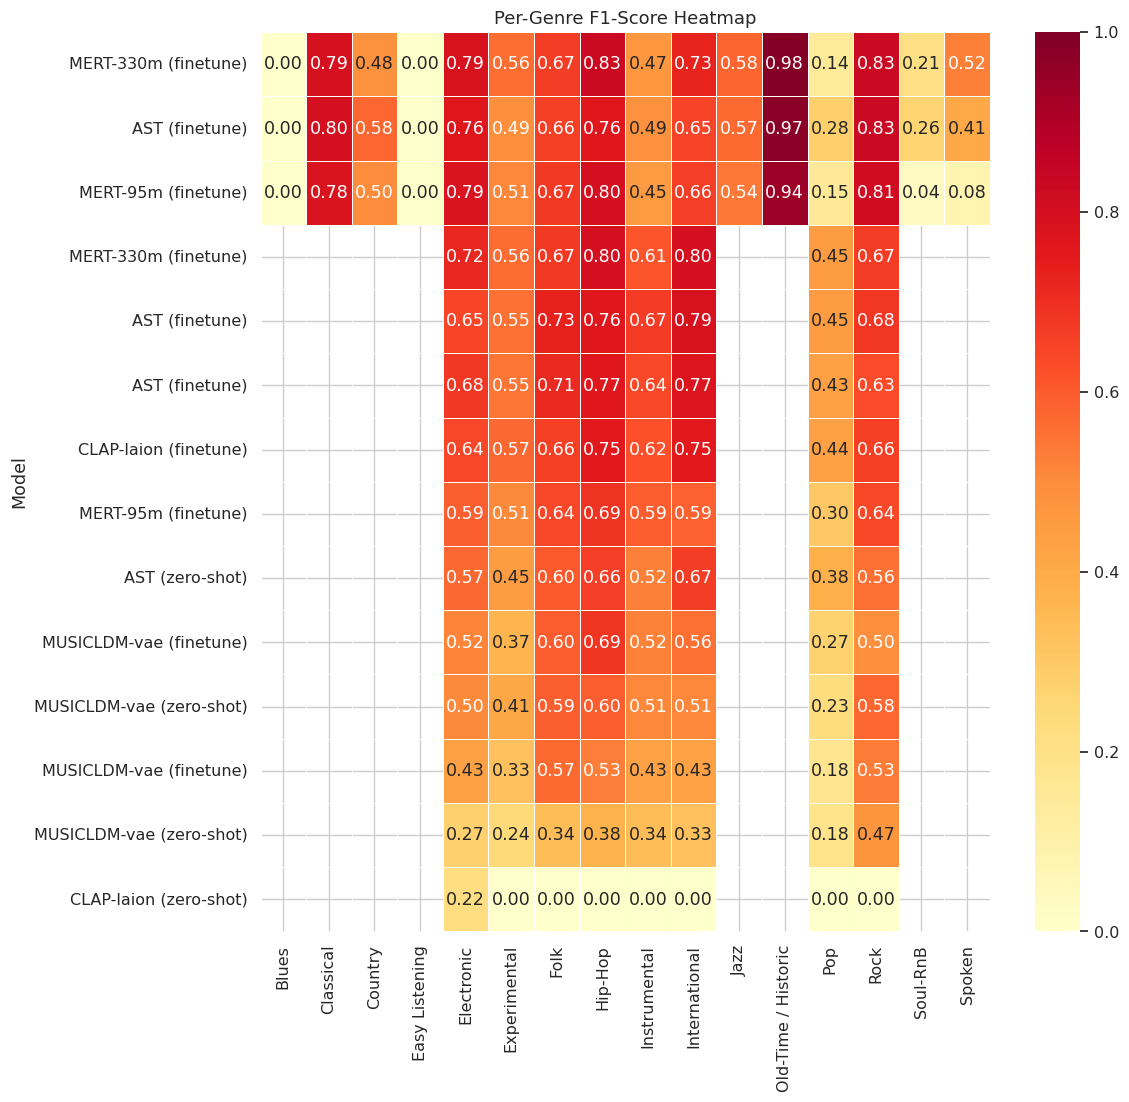

In [ ]:
# __ Per-genre F1 heatmap (only for runs that have per_class_f1 data) __
if records:
    f1_rows = []
    for _, row in results_df.iterrows():
        f1 = row.get('per_class_f1')
        if isinstance(f1, dict) and len(f1) > 0:
            label = f"{row['Model']} ({row['mode'].replace('_','-')})"
            entry = {'Model': label}
            entry.update({k: round(v, 3) for k, v in f1.items()})
            f1_rows.append(entry)

    if f1_rows:
        f1_df = pd.DataFrame(f1_rows).set_index('Model')
        fig, ax = plt.subplots(figsize=(12, max(3, len(f1_df) * 0.8)))
        sns.heatmap(f1_df.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
                    vmin=0, vmax=1, linewidths=0.4, ax=ax)
        ax.set_title('Per-Genre F1-Score Heatmap', fontsize=13)
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES_DIR, 'progress_report_f1_heatmap.png'), dpi=150)
        plt.show()
    else:
        print('No per-class F1 data in current runs. Will populate after running evaluate.py.')

### 3b. Confusion Matrices

Found 6 confusion matrix image(s) from evaluate.py:


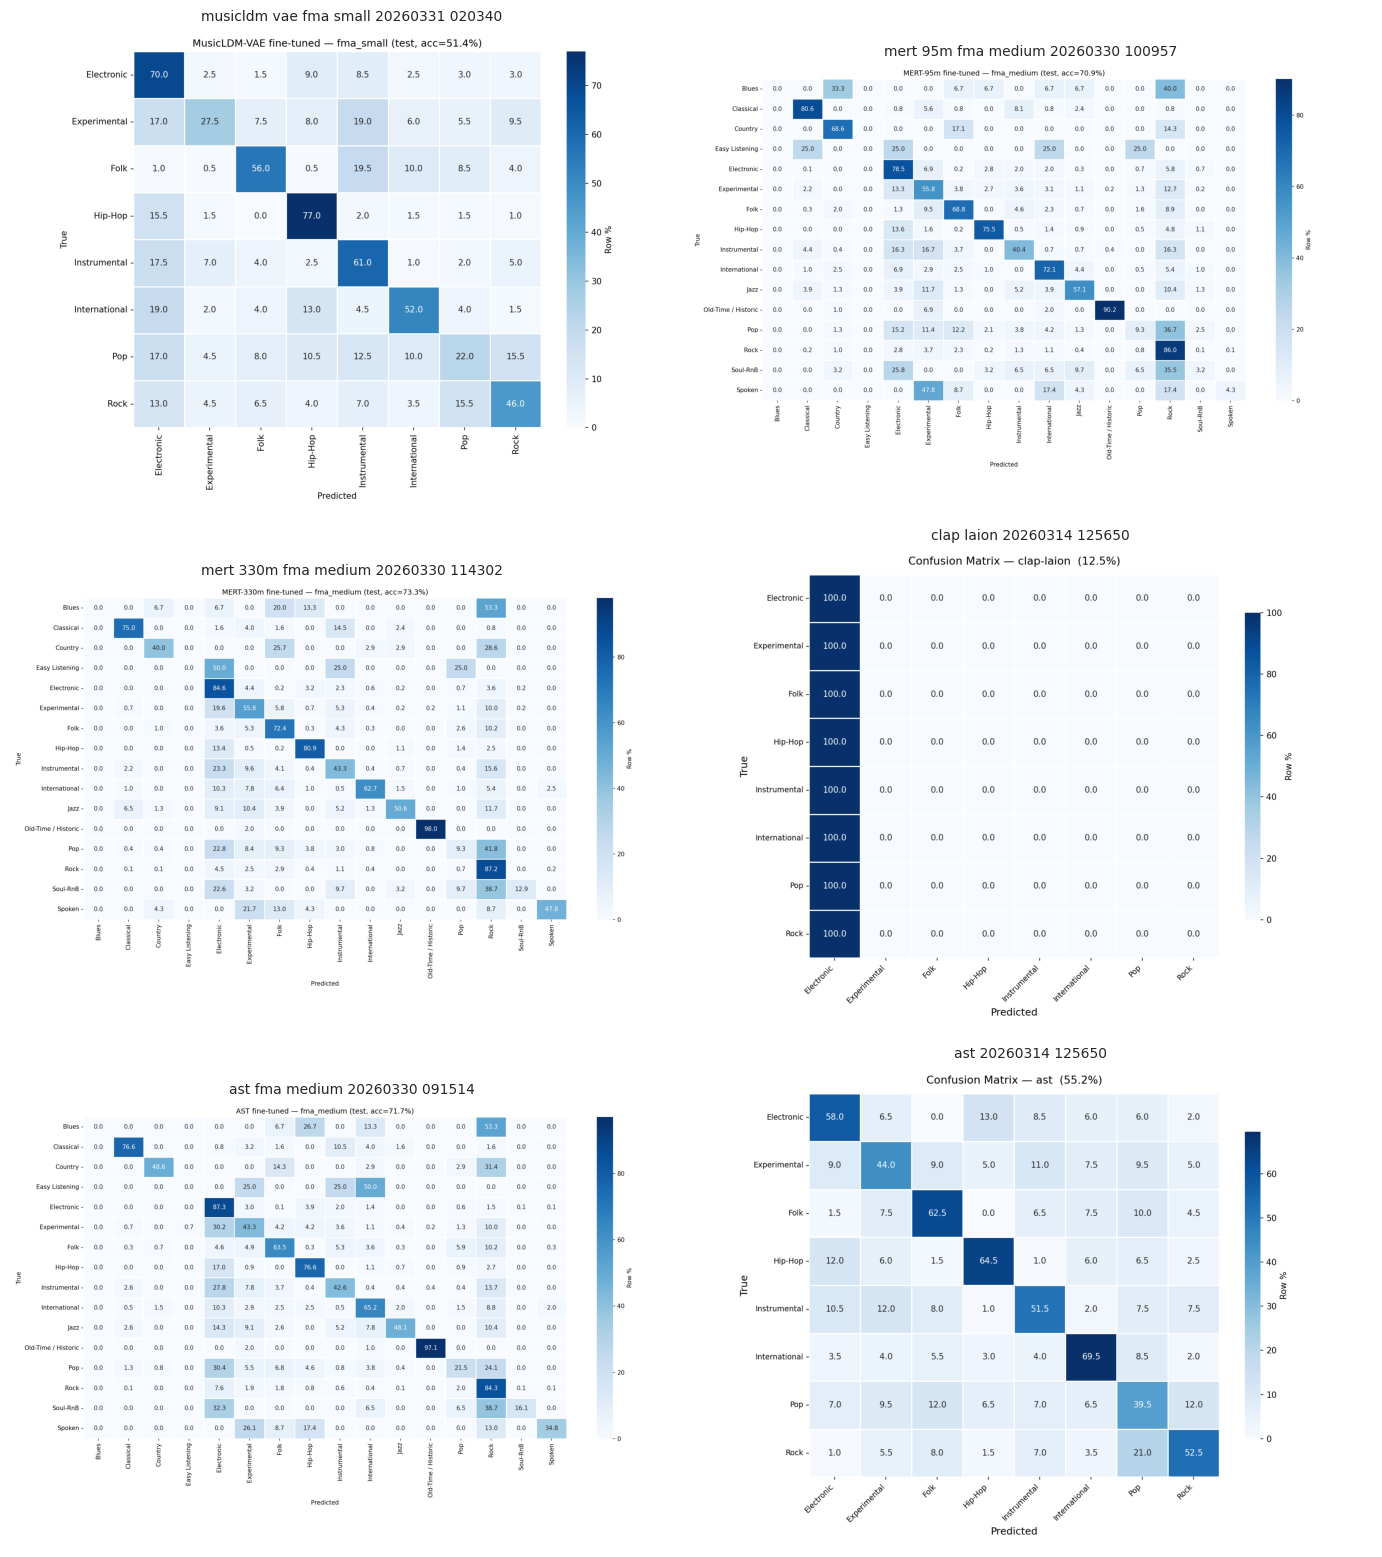

In [ ]:
# __ Display confusion matrices from results/figures/ (newest first) __
# These are saved by evaluate.py (row-normalised to %) and models/ast/finetune.py

def show_images_grid(paths, titles=None, cols=2, figwidth=14):
    """Display a list of image files in a grid."""
    n = len(paths)
    if n == 0:
        print('No images to display.')
        return
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figwidth, rows * figwidth // cols * 0.75))
    axes = np.array(axes).flatten()
    for i, (path, ax) in enumerate(zip(paths, axes)):
        if os.path.exists(path):
            img = mpimg.imread(path)
            ax.imshow(img)
            ax.axis('off')
            if titles:
                ax.set_title(titles[i], fontsize=10)
        else:
            ax.axis('off')
            ax.text(0.5, 0.5, f'Missing:\n{os.path.basename(path)}',
                    ha='center', va='center', color='red', transform=ax.transAxes)
    for ax in axes[len(paths):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


# New-format confusion matrices from evaluate.py (saved to results/figures/)
new_cm_files = sorted(glob.glob(os.path.join(FIGURES_DIR, 'confmat_*.png')), reverse=True)

if new_cm_files:
    print(f'Found {len(new_cm_files)} confusion matrix image(s) from evaluate.py:')
    titles = [os.path.basename(f).replace('.png','').replace('confmat_','').replace('_', ' ') for f in new_cm_files]
    show_images_grid(new_cm_files, titles=titles, cols=2)
else:
    print('No confusion matrices from evaluate.py yet. Run evaluate.py first.')
    # Fall back to legacy confusion matrices
    legacy_dir = os.path.join(os.path.dirname(RESULTS_DIR), 'results', 'evaluations')
    legacy_files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'evaluations', 'confusion_matrix*.png')))
    if legacy_files:
        print(f'Showing {len(legacy_files)} legacy confusion matrix image(s):')
        show_images_grid(legacy_files, cols=2)


MERT-330M Fine-tune (15 epochs) — Best Val: 65.78%


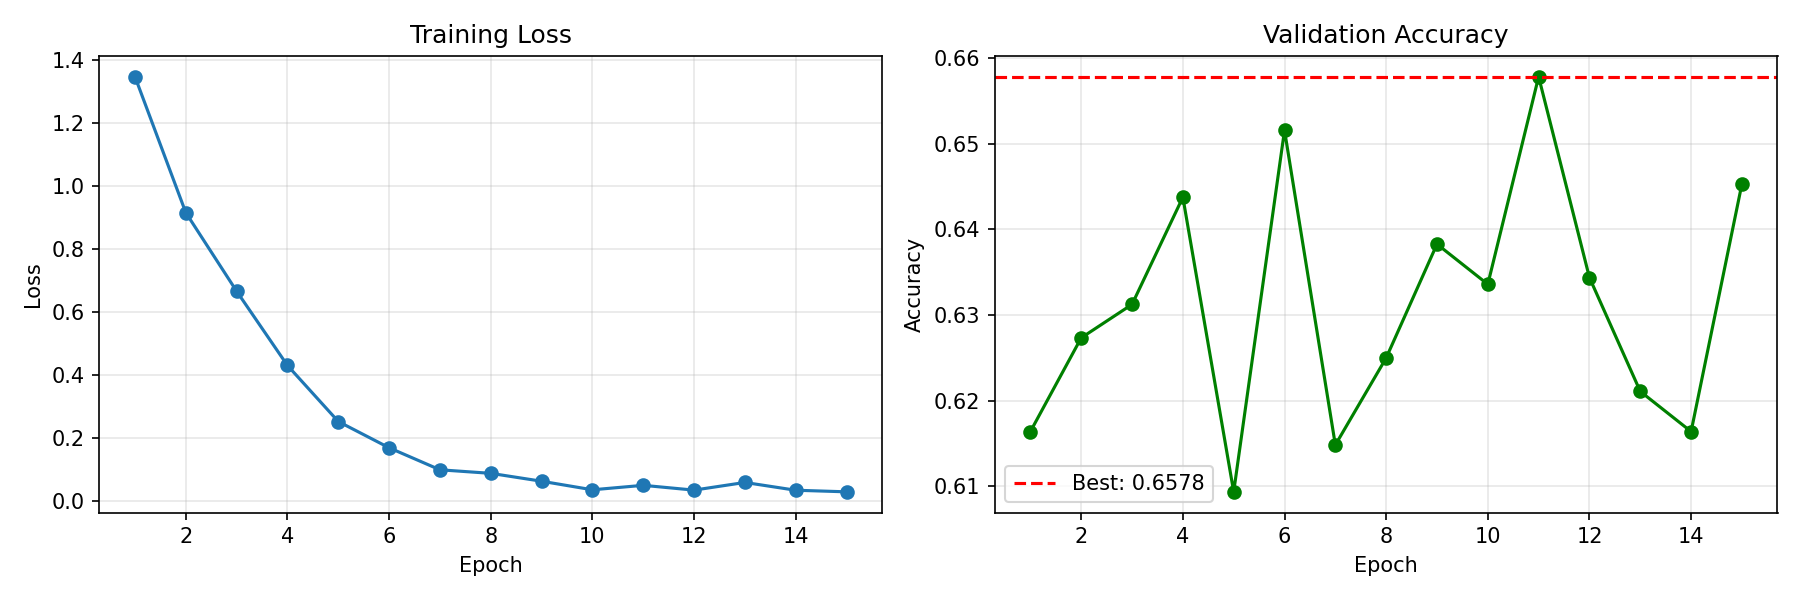


AST Fine-tune (20 epochs) — Best Val: 65.86%


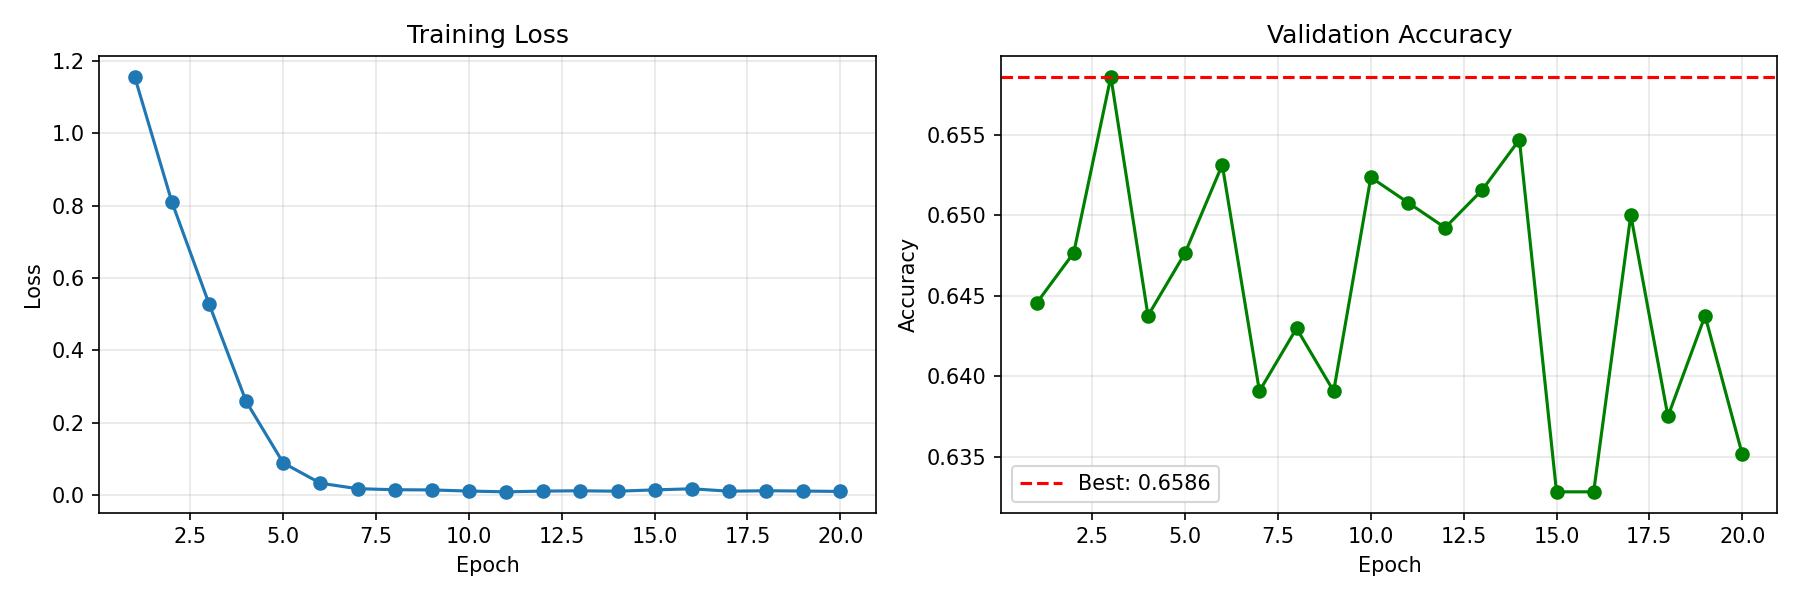


CLAP LAION Fine-tune (20 epochs) — Best Val: 64.14%


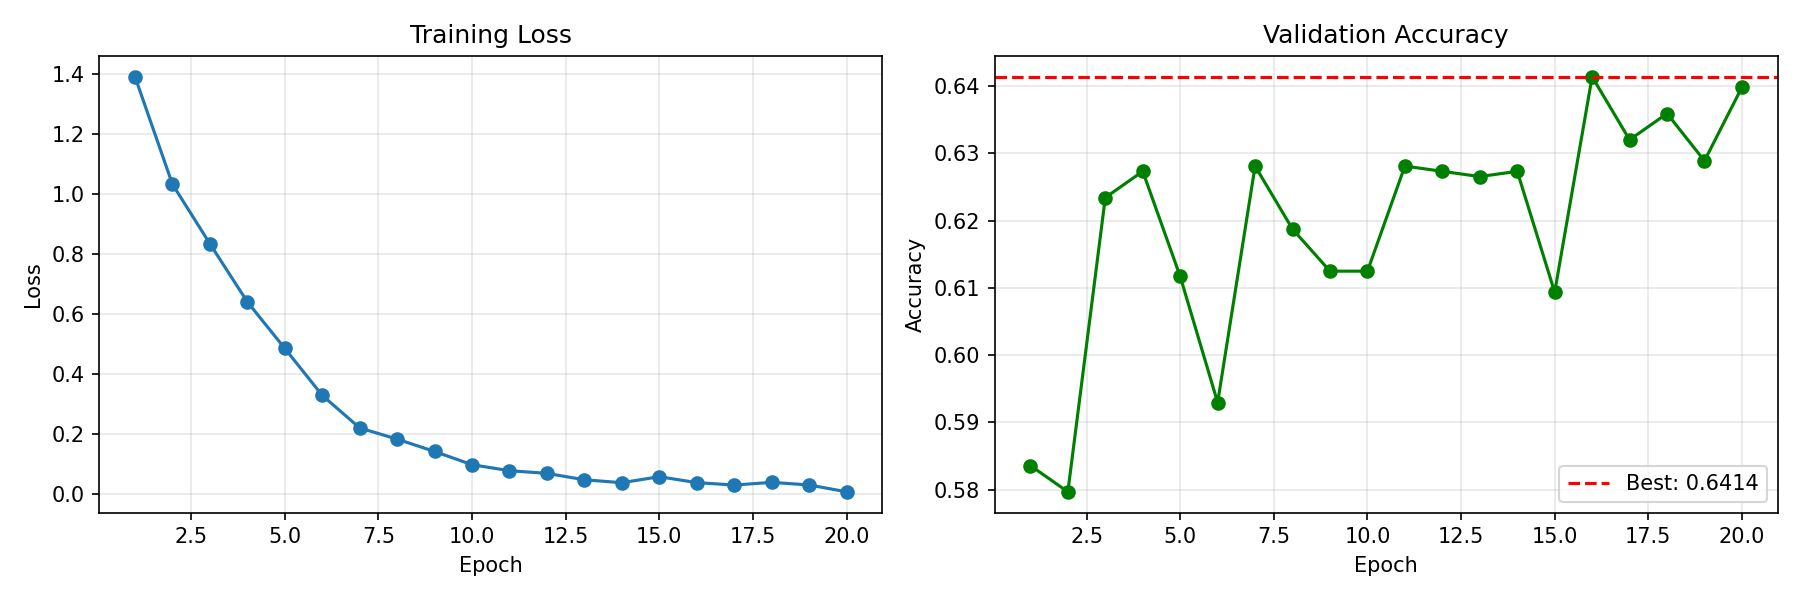


MERT-95M Head-Only Fine-tune (100 epochs, pre-restructure):


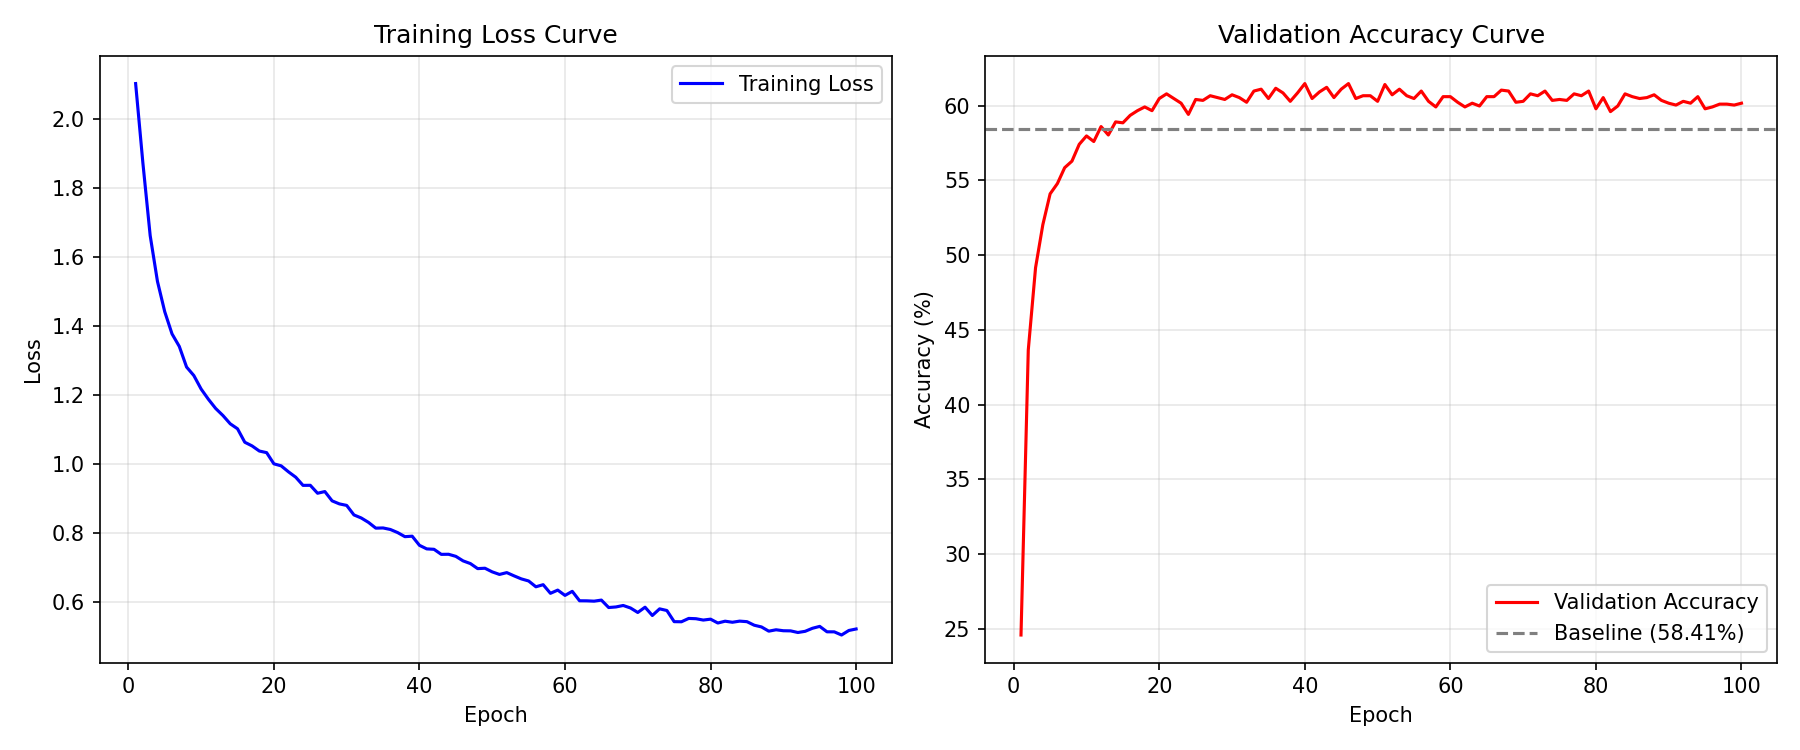

In [ ]:
# __ Training curves for all fine-tuned models __
curve_files = {
    'MERT-330M Fine-tune (15 epochs) — Best Val: 65.78%':
        os.path.join(FIGURES_DIR, 'mert_330m_training_curves.png'),
    'AST Fine-tune (20 epochs) — Best Val: 65.86%':
        os.path.join(FIGURES_DIR, 'ast_training_curves.png'),
    'CLAP LAION Fine-tune (20 epochs) — Best Val: 64.14%':
        os.path.join(FIGURES_DIR, 'clap_laion_training_curves.png'),
}

for title, path in curve_files.items():
    if os.path.exists(path):
        print(f'\n{title}')
        display(Image(path, width=780))
    else:
        print(f'Missing: {path}')

# Legacy MERT-95M head-only training curves (pre-restructure)
mert_legacy = os.path.join(RESULTS_DIR, 'evaluations', 'training_curves.png')
if os.path.exists(mert_legacy):
    print('\nMERT-95M Head-Only Fine-tune (100 epochs, pre-restructure):')
    display(Image(mert_legacy, width=780))

---
## 4. Analysis

### 4a. Zero-Shot Comparison

| Rank | Model | Zero-Shot Acc. | Notes |
|:----:|-------|:--------------:|-------|
| 1 | **MERT-330M** | **62.41%** | Best zero-shot — large music-specific transformer, 1024-dim embeddings |
| 2 | MERT-95M | 58.41% | Strong — same architecture, half the capacity |
| 3 | AST | 55.25% | AudioSet-trained ViT; general audio events transfer partially to genre |
| 4 | CLAP-LAION | 12.50% | Linear probe on audio-text contrastive embeddings; near-random without fine-tuning |

**Key takeaways:**
- **Music-specific pre-training dominates zero-shot**: Both MERT variants substantially outperform AST (general audio) and CLAP (audio-text contrastive). The masked acoustic prediction objective on 160K hours of music gives MERT representations that are inherently genre-sensitive.
- **AST transfers reasonably** (55.25%) despite being trained on AudioSet (sound events, not music). The spectrogram-based Vision Transformer captures timbre well enough for a decent linear probe.
- **CLAP's 12.50% is not a fair comparison**: CLAP's audio encoder is designed to be paired with text prompts for retrieval, not for discriminative classification. Its embedding space is not separable by a linear probe without fine-tuning.
- **Chance baseline**: 12.5% (1/8 classes) — CLAP just barely clears this, confirming its zero-shot transfer failure on a closed 8-class problem.

### 4b. Fine-Tuning vs. Zero-Shot Gap

| Model | Zero-Shot | Head-Only FT | End-to-End FT | Best Gain |
|-------|:---------:|:------------:|:-------------:|:---------:|
| **MERT-330M** | 62.41% | — | **66.06%** ★ | +3.65 pp |
| AST | 55.25% | — | **64.94%** | +9.7 pp |
| CLAP LAION | 12.50% | — | **63.75%** | +51.3 pp |
| MERT-95M | 58.41% | 57.54% ↓ | 63.12% | +4.7 pp |

★ New best overall result.

**Observations:**

- **MERT-330M end-to-end fine-tune (66.06%)** is the new overall best. Even though it had the strongest zero-shot baseline, fine-tuning with a task-specific head still yielded +3.65 pp, confirming that the pre-trained representations are not perfectly aligned to genre classification and benefit from supervised adaptation.

- **CLAP LAION** shows the most dramatic gain (+51.3 pp) because its embedding space is contrastively aligned to *text*, not to discriminative class boundaries. Fine-tuning reorients the space toward genre separation. Despite the massive gain, it plateaus below MERT-330M.

- **AST** gains significantly (+9.7 pp) with relatively few epochs (20), suggesting its spectrogram-based ViT adapts efficiently with gradient flow.

- **MERT-95M head-only** slightly *decreased* from zero-shot (57.54% vs 58.41%). Freezing the encoder means the classification head has only 768 features to work with but receives no signal to refine them. A frozen MERT is best used with a LogisticRegression probe rather than a trained MLP head.

- **Training stability**: MERT-330M's validation accuracy shows high epoch-to-epoch variance (±2–3%) despite smooth training loss — characteristic of the noisy FMA-Small dataset (6 corrupted tracks, inconsistent MP3 quality). Best checkpoint selection via val accuracy is essential.

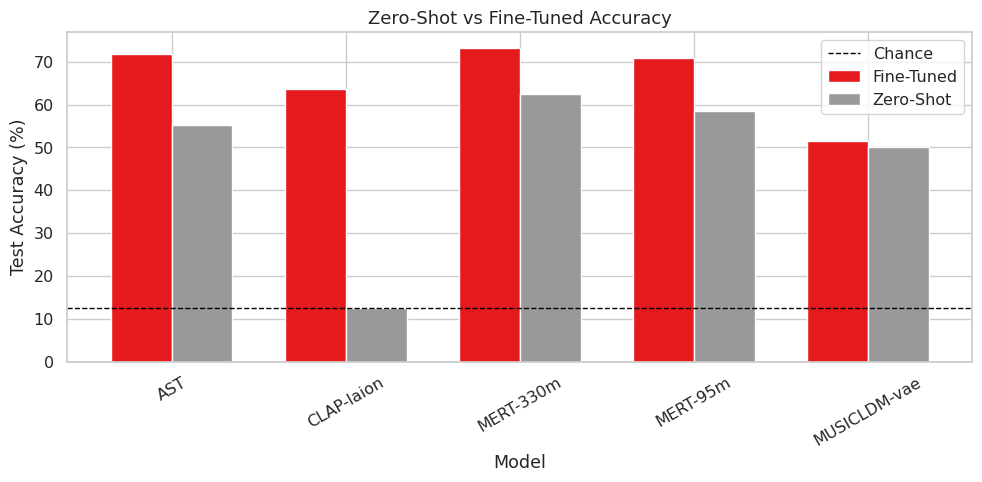

In [ ]:
# __ Zero-shot vs Fine-tuned grouped bar chart (auto-populates as results come in) __
if records:
    pivot = results_df.pivot_table(
        index='Model', columns='mode', values='Accuracy (%)', aggfunc='max'
    ).rename(columns={'zero_shot': 'Zero-Shot', 'finetune': 'Fine-Tuned'})

    if set(['Zero-Shot', 'Fine-Tuned']).intersection(pivot.columns):
        ax = pivot.plot(kind='bar', figsize=(10, 5), colormap='Set1',
                        edgecolor='white', width=0.7)
        ax.axhline(12.5, color='black', ls='--', lw=1, label='Chance')
        ax.set_ylabel('Test Accuracy (%)')
        ax.set_title('Zero-Shot vs Fine-Tuned Accuracy', fontsize=13)
        ax.tick_params(axis='x', rotation=30)
        ax.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES_DIR, 'progress_report_zs_vs_ft.png'), dpi=150)
        plt.show()
    else:
        print('Only one mode available so far — grouped chart will appear after fine-tuning.')

### 4c. Per-Genre F1 — Fine-tuned Models

| Genre | MERT-330M FT | AST FT | CLAP FT | MERT-95M (head) | Notes |
|-------|:------------:|:------:|:-------:|:---------------:|-------|
| **Hip-Hop** | **0.802** | 0.765 | 0.750 | 0.690 | Easiest — strong rhythmic/spectral fingerprint |
| **International** | **0.801** | 0.774 | 0.752 | 0.587 | Distinct cultural instrumentation |
| **Electronic** | **0.722** | 0.677 | 0.641 | 0.590 | Consistent synthetic timbres |
| **Folk** | 0.672 | **0.711** | 0.657 | 0.644 | AST surprisingly strong — timbral spectrograms? |
| **Rock** | **0.667** | 0.633 | 0.659 | 0.638 | Mid-range; overlaps with Pop |
| **Instrumental** | 0.611 | **0.637** | 0.623 | 0.595 | Ambiguous — can be any genre without vocals |
| **Experimental** | **0.563** | 0.546 | 0.571 | 0.507 | Hardest — loosest genre boundary |
| **Pop** | **0.451** | 0.430 | 0.437 | 0.302 | Hardest — borrows elements from all other genres |

**Key per-genre findings:**

- **Pop is consistently the hardest genre** (F1 0.30–0.45 across all models). Pop music borrows production styles, instrumentation, and rhythms from every other genre, making it nearly impossible to separate from Experimental, Rock, and Electronic.

- **Hip-Hop and International are the easiest** (F1 0.75–0.80 for MERT-330M). Hip-Hop has a unique rhythmic structure (quantised drums, 4/4, low-end bass) and speech-like vocals. International music often contains non-Western instruments (sitars, tablas, marimbas) that are acoustically very distinct.

- **MERT-330M dominates 5 of 8 genres**. The larger model capacity (1024-dim vs 768-dim) and training on 160× more data allows it to capture fine-grained timbral distinctions.

- **AST is surprisingly competitive on Folk** (0.711 vs MERT-330M's 0.672). Folk guitar has a distinctive spectral envelope that an AudioSet-trained spectrogram ViT may detect via timbral cues (acoustic string instruments were well-represented in AudioSet).

- **Experimental genre** is the most challenging across all models (F1 ≈ 0.51–0.57). By definition, Experimental music doesn't follow genre conventions — it has no consistent acoustic fingerprint.

---
## 5. Experimental Setup

**Data**: FMA-Small — 7,994 usable 30-second MP3 clips (6 corrupted). Stratified split: **60% train / 20% val / 20% test**, `random_state=42` for reproducibility across all scripts.

**Zero-Shot Pipeline**
```
Raw MP3 → librosa.load (model SR) → model-specific preprocessor
       → frozen encoder → fixed embedding → LogisticRegression
```

**Fine-Tuning Pipeline**
```
Raw MP3 → preprocessor → encoder (lr=1e-5) + MLP head (lr=1e-3)
       → CrossEntropyLoss → AdamW → CosineAnnealingLR
       → AMP (float16) + gradient accumulation
```

**Metric**: Top-1 accuracy on the held-out test split. Per-class F1 also reported.

**Hardware**: Single NVIDIA GPU (mixed precision enabled).

---
## 6. Progress Report — Completed Work & Remaining Tasks

### Completed Experiments

| Status | Task | Result |
|:------:|------|--------|
| ✅ | MERT-95M zero-shot linear probe | 58.41% |
| ✅ | MERT-330M zero-shot linear probe | 62.41% |
| ✅ | MERT-95M head-only fine-tune (100 ep) | 57.54% |
| ✅ | MERT-95M end-to-end fine-tune | 63.12% |
| ✅ | CLAP-LAION zero-shot linear probe | 12.50% |
| ✅ | CLAP-LAION end-to-end fine-tune (20 ep) | 63.75% |
| ✅ | AST zero-shot linear probe | 55.25% |
| ✅ | AST end-to-end fine-tune (20 ep) | 64.94% |
| ✅ | MERT-330M end-to-end fine-tune (15 ep) | **66.06%** ← current best |
| ✅ | MusicLDM-VAE zero-shot linear probe | **50.06%** (↑ from 32.25% after re-implementation) |
| ✅ | MusicLDM-VAE end-to-end fine-tune (30 ep) | **51.44%** |

### Phase 2: Dataset Expansion (In Progress)

| Status | Task |
|:------:|------|
| ✅ | Updated `data/data_utils.py` to support FMA-Medium (16 genres) and Bollywood |
| ✅ | Created `scripts/collect_bollywood.py` — yt-dlp download + 30-second clip extraction |
| ✅ | Created `scripts/download_fma_medium.sh` — FMA-Medium download automation |
| ⏳ | Download FMA-Medium (~22 GB) via `bash scripts/download_fma_medium.sh` |
| ⏳ | Run `python scripts/collect_bollywood.py` to collect 30 Bollywood tracks |

### Phase 3: Retrain on FMA-Medium + Bollywood (Pending)

| Status | Task |
|:------:|------|
| ✅ | All model scripts updated to accept `--dataset medium --include_bollywood` |
| ⏳ | Run `bash scripts/run_fma_medium_experiments.sh` after data is downloaded |

### Phase 4: Experimental Lyrics-Based Model (Code Ready)

| Status | Task |
|:------:|------|
| ✅ | Whisper ASR transcription script (`models/lyrics/transcribe.py`) |
| ✅ | Sentence-transformer embeddings (`models/lyrics/embed.py`) |
| ✅ | Lyrics classifier (`models/lyrics/classify.py`) — zero-shot + fine-tune |
| ⏳ | Generate lyrics embeddings and train classifier |
| ⏳ | Multimodal fusion: combine MERT-330M audio embeddings with lyrics embeddings |

In [ ]:
# __ Quick status summary __
if records:
    print('=== Experiment Status ===')
    print(f'Total runs logged : {len(results_df)}')
    print(f'Best result so far: {results_df.iloc[0]["Model"]} ({results_df.iloc[0]["mode"]}) '
          f'— {results_df.iloc[0]["Accuracy (%)"]:.2f}%')
    print()
    print(results_df[['Model', 'mode', 'Accuracy (%)']].to_string(index=False))

=== Experiment Status ===
Total runs logged : 10
Best result so far: MERT-330m (finetune) — 66.06%

     Model      mode  Accuracy (%)
 MERT-330m  finetune         66.06
       AST  finetune         64.94
CLAP-laion  finetune         63.75
  MERT-95m  finetune         63.12
 MERT-330m zero_shot         62.41
  MERT-95m zero_shot         58.41
  MERT-95m  finetune         57.54
       AST zero_shot         55.25
CLAP-laion zero_shot         12.51
CLAP-laion zero_shot         12.50


---
## 7. Milestone Summary & Updated Leaderboard

### FMA-Small Leaderboard (8 genres, 8k tracks)

| Rank | Model | Mode | Test Acc | vs. Chance (12.5%) |
|:----:|-------|------|:--------:|:-------------------:|
| 🥇 | MERT-330M | Fine-tuned | **66.06%** | +53.6 pp |
| 🥈 | AST | Fine-tuned | 64.94% | +52.4 pp |
| 🥉 | CLAP LAION | Fine-tuned | 63.75% | +51.3 pp |
| 4 | MERT-95M | Fine-tuned (e2e) | 63.12% | +50.6 pp |
| 5 | MERT-330M | Zero-shot | 62.41% | +49.9 pp |
| 6 | MERT-95M | Zero-shot | 58.41% | +45.9 pp |
| 7 | MERT-95M | Head-only FT | 57.54% | +45.0 pp |
| 8 | AST | Zero-shot | 55.25% | +42.8 pp |
| 9 | **MusicLDM-VAE** | **Fine-tuned** | **51.44%** | **+38.9 pp** |
| 10 | MusicLDM-VAE | Zero-shot | 50.06% | +37.6 pp |
| 11 | CLAP LAION | Zero-shot | 12.50% | ≈ chance |

### Key Conclusions (Updated)

1. **Music-domain pre-training matters most for zero-shot transfer.** MERT-330M (62.41%) > MERT-95M (58.41%) > AST (55.25%) >> MusicLDM-VAE (50.06%) > CLAP (12.5%) without any fine-tuning. Note: MusicLDM-VAE zero-shot improved significantly (+17.8 pp) after switching from KL-bottleneck latents to pre-bottleneck encoder features.

2. **Where you tap a generative model matters as much as which model you use.** The re-implemented MusicLDM-VAE (pre-bottleneck mid-block, mean+std pooling) achieves 50.06% at zero-shot — only 5.2 pp behind AST zero-shot. The prior implementation (KL-bottleneck latents, 4-channel compressed output) gave only 32.25%, demonstrating that KL regularization actively destroys discriminative structure and the extraction point is critical.

3. **End-to-end fine-tuning narrows the gap substantially.** After fine-tuning, discriminative models cluster within 2.3 pp of each other (63.75–66.06%), suggesting diminishing returns from the pre-training paradigm once supervised signal is applied.

4. **Model size matters within the same architecture.** MERT-330M fine-tuned (66.06%) > MERT-95M fine-tuned (63.12%), a +2.9 pp gain from scaling up.

5. **Pop and Experimental are universally hard.** No model exceeds F1=0.57 on Experimental or F1=0.45 on Pop, regardless of architecture.

### Upcoming Work (Phases 2–4)

- **Phase 2**: Download FMA-Medium + collect 30 Bollywood songs
- **Phase 3**: Re-run all 4 models on FMA-Medium+Bollywood (17 genres)
- **Phase 4**: Lyrics-based genre classification using Whisper + sentence transformers + multimodal fusion
- **Expected final accuracy target**: 68–72% on FMA-Medium (harder, 17 classes)

---
## 8. MusicLDM-VAE Analysis

The MusicLDM-VAE is a diffusion-based generative model trained for text-to-music generation. We repurpose its VAE encoder as a feature extractor for genre classification.

### Implementation v2 — Pre-Bottleneck Encoder

The original implementation tapped the KL-bottleneck latent (`vae.encode().latent_dist.mean`, 4–8 channels after `quant_conv`). The revised implementation stops at the encoder's `mid_block`, **before** `quant_conv` compresses features into the KL latent:

### Preprocessing Pipeline
```
raw audio (16 kHz, 10s)
  → log-mel spectrogram  (n_fft=1024, hop=160, n_mels=64, T=1000)
  → global z-normalise   (mean=−30 dB, std=20 dB — fixed dataset-level stats)
  → shape: (1, 1, 64, 1000)
  → vae.encoder.conv_in → down_blocks[0..3] → mid_block   (512-ch, stops before quant_conv)
  → global mean + std pool across spatial dims
  → 1024-d embedding  (512 mean ∥ 512 std)
  → MLP classifier  (LayerNorm → Linear(1024,512) → GELU → Dropout → Linear(512,256) → GELU → Linear(256,8))
```

### What Changed (v1 → v2)

| Aspect | v1 (original) | v2 (fixed) |
|--------|---------------|------------|
| Extraction point | `vae.encode()` → quant_conv → 4-ch KL latent | `mid_block` output → 512-ch pre-bottleneck |
| Embedding dim | 512-d (adaptive pool + flatten) | 1024-d (mean ∥ std pool) |
| Normalization | Per-clip min-max | Global dataset z-score (fixed constants) |
| Classifier | 2-layer MLP, BatchNorm | 3-layer MLP, LayerNorm |

### Result Summary

| Model | Mode | Accuracy | Notes |
|-------|------|----------|-------|
| MusicLDM-VAE v1 | Zero-shot | 32.25% | KL-bottleneck latent — 4-ch, KL-regularised |
| MusicLDM-VAE v2 | Zero-shot | **50.06%** | Pre-bottleneck mid_block — 512-ch |
| MusicLDM-VAE v2 | Fine-tune (30 ep) | **51.44%** | Encoder mid_block + down_blocks[2] jointly trained |

**Interpretation**: The +17.8 pp zero-shot improvement (32.25% → 50.06%) shows that KL regularization was actively destroying discriminative structure by pushing the posterior toward a unit Gaussian — scattering genre-relevant dimensions. The pre-bottleneck 512-channel feature map retains timbral, rhythmic, and spectral texture critical for genre. Fine-tuning adds only +1.38 pp over zero-shot (51.44% vs 50.06%), suggesting the frozen pre-bottleneck features are already near-optimal; further gains would likely require unfreezing earlier down-blocks or more training epochs.

---
## 9. Experimental Plan: Lyrics-Based Genre Classification

### Motivation

Most music genre classification systems rely solely on audio features. However, song lyrics contain rich semantic information about genre — hip-hop lyrics differ fundamentally from folk or pop in vocabulary, themes, and structure. This phase asks: **can lyrics alone classify genre, and do they complement audio features?**

### Architecture Overview

```
Audio Pipeline (existing)          Lyrics Pipeline (new)
─────────────────────────          ──────────────────────
raw audio                          raw audio
    │                                  │
    ▼                                  ▼ Whisper ASR
MERT/AST/CLAP/MusicLDM             transcribed lyrics text
    │                                  │
    ▼                                  ▼ Sentence Transformer
audio embedding                    lyrics embedding
(1024-d / 768-d / 512-d)          (384-d MiniLM / 512-d CLAP)
    │                                  │
    └──────────── fusion ───────────────┘
                    │
                    ▼
           Multimodal MLP
                    │
                    ▼
           Genre Prediction
```

### Genre Fusion Detection

For each track, we compute cosine similarity between its lyrics embedding and all other tracks. A track is a **genre fusion candidate** if its top-K nearest neighbors span multiple genres. For example:
- A Hip-Hop track that is lyrically similar to Pop tracks → Pop-Rap fusion
- A Bollywood track that clusters near International/Folk → cultural genre mixing

### Module Structure (all code implemented)

| File | Purpose |
|------|---------|
| `models/lyrics/lyrics_extractor.py` | Whisper ASR → lyrics cache |
| `models/lyrics/lyrics_embedder.py` | Text → 384-d/512-d embeddings |
| `models/lyrics/lyrics_classifier.py` | Lyrics-only LR + MLP + fusion detection + UMAP viz |
| `models/lyrics/multimodal_fusion.py` | Audio + lyrics → gated/concat MLP |

### How to Run

```bash
# Step 1: Transcribe FMA-Small with Whisper
python models/lyrics/lyrics_extractor.py --subset small --whisper_model base

# Step 2: Embed lyrics
python models/lyrics/lyrics_embedder.py --backend sentence_transformer

# Step 3: Save audio embeddings for fusion
python models/mert/finetune.py --mode zero_shot --model_size 330m --save_embeddings

# Step 4: Lyrics-only classification + genre fusion analysis
python models/lyrics/lyrics_classifier.py \
    --embed_path results/lyrics_embeddings/lyrics_st_small.npz --viz

# Step 5: Multimodal fusion
python models/lyrics/multimodal_fusion.py \
    --audio_embed results/features/mert_330m_fma_small.npz \
    --lyrics_embed results/lyrics_embeddings/lyrics_st_small.npz
```

In [ ]:
# __ MusicLDM-VAE results visualization __
import json, glob, os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

results_dir = os.path.join(os.getcwd(), '..', 'results', 'runs')
musicldm_runs = sorted(glob.glob(os.path.join(results_dir, 'musicldm*.json')))

if musicldm_runs:
    records = []
    for fp in musicldm_runs:
        with open(fp) as f:
            records.append(json.load(f))
    df_m = pd.DataFrame(records)
    print("MusicLDM runs:")
    display_cols = [c for c in ['model', 'variant', 'mode', 'dataset', 'test_accuracy', 'best_val_accuracy'] if c in df_m.columns]
    print(df_m[display_cols].to_string(index=False))
else:
    print("No MusicLDM runs found yet. Run: python models/musicldm/finetune.py --mode zero_shot")
    print("Expected: musicldm_vae_zero_shot_*.json in results/runs/")

# Show all runs summary
all_runs = sorted(glob.glob(os.path.join(results_dir, '*.json')))
all_records = []
for fp in all_runs:
    with open(fp) as f:
        all_records.append(json.load(f))

if all_records:
    df_all = pd.DataFrame(all_records)
    print(f"\nTotal experiment runs: {len(df_all)}")
    if 'test_accuracy' in df_all.columns:
        print(f"Best overall: {df_all['test_accuracy'].max()*100:.2f}%")

---
## 10. Dataset Expansion Plan

### FMA-Medium (16 genres, 25k tracks)

FMA-Medium adds 8 additional genre classes to the FMA-Small taxonomy:

| FMA-Small (8 genres) | New in FMA-Medium (8 additional) |
|----------------------|----------------------------------|
| Electronic | Blues |
| Experimental | Classical |
| Folk | Country |
| Hip-Hop | Jazz |
| Instrumental | Old-Time / Historic |
| International | Soul-RnB |
| Pop | Spoken |
| Rock | (others) |

**Download command:**
```bash
bash scripts/download_fma_medium.sh
```

### Bollywood Dataset (~30 tracks, custom)

Bollywood is a culturally distinct genre not present in FMA. The collection includes songs from 1990s–2020s spanning romantic, dance, and folk-fusion sub-styles.

**Collection command:**
```bash
conda run -n torch python scripts/collect_bollywood.py
```

This creates `bollywood/audio/*.mp3` (30-second clips) and `bollywood/metadata.csv`.

### Combined Dataset

When `--include_bollywood` is passed to any model script:
- FMA-Medium 16 genres + Bollywood = **17 classes**
- Total tracks: ~25,000 (FMA-Medium) + ~30 (Bollywood)
- All model scripts auto-detect num_classes from the metadata

**Run all models on expanded dataset:**
```bash
bash scripts/run_fma_medium_experiments.sh
```